In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [7]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [8]:
matches.isnull().sum().sort_values(ascending=False)

method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
target_overs          3
id                    0
date                  0
season                0
venue                 0
match_type            0
toss_decision         0
toss_winner           0
team2                 0
team1                 0
result                0
super_over            0
umpire1               0
umpire2               0
dtype: int64

In [9]:
team_wins = matches['winner'].value_counts()

team_wins.head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

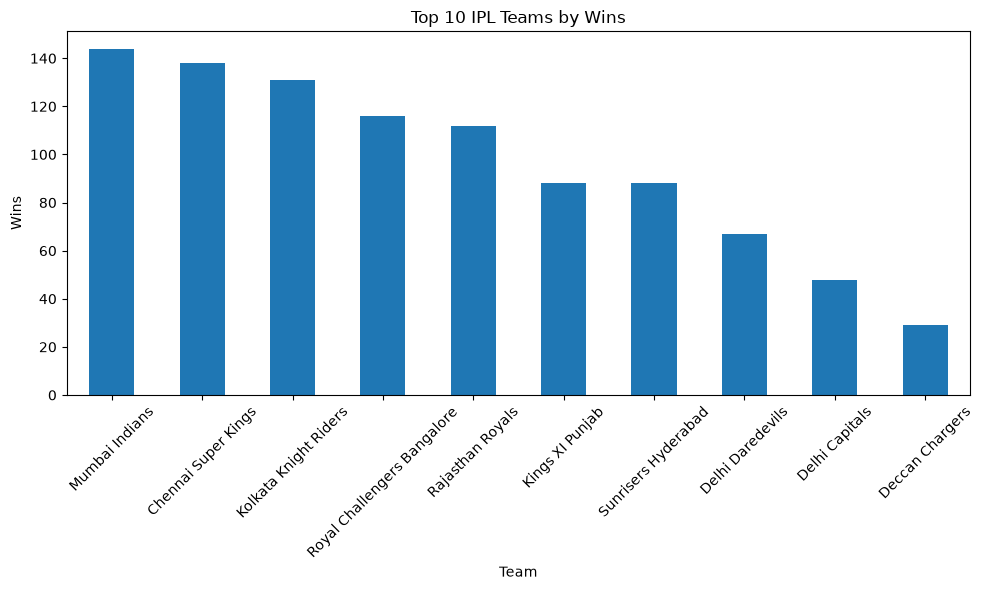

In [11]:
plt.figure(figsize=(10,6))

team_wins.head(10).plot(kind='bar')

plt.title("Top 10 IPL Teams by Wins")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/images/team_wins.png")

plt.show()

In [12]:
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

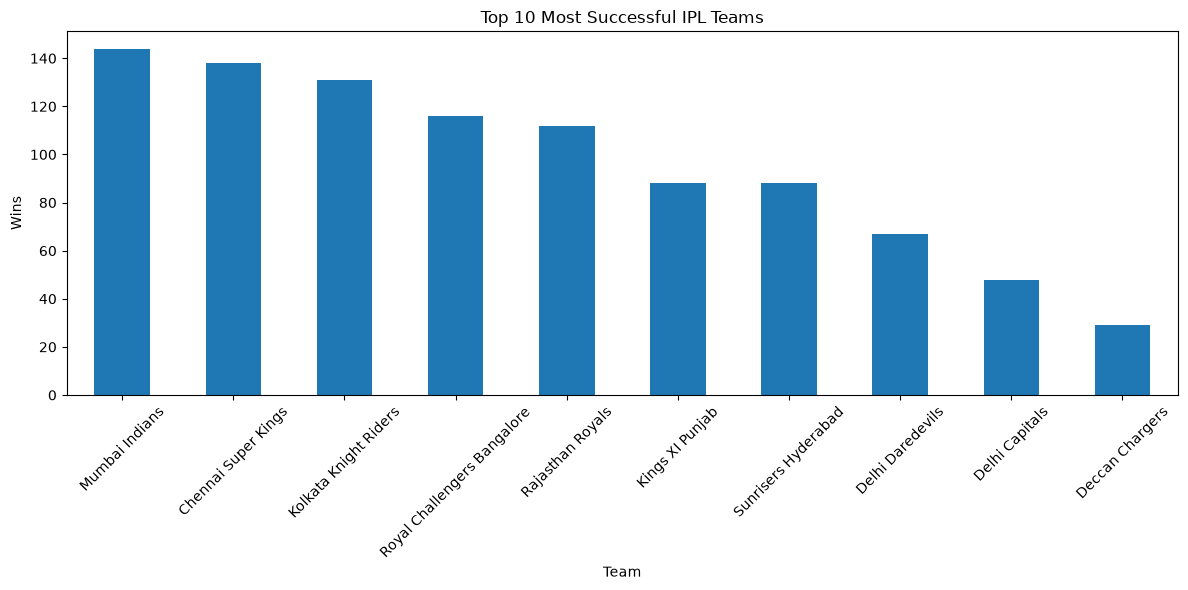

In [14]:
plt.figure(figsize=(12,6))

matches['winner'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Most Successful IPL Teams')
plt.xlabel('Team')
plt.ylabel('Wins')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../reports/images/top_teams.png')
plt.show()

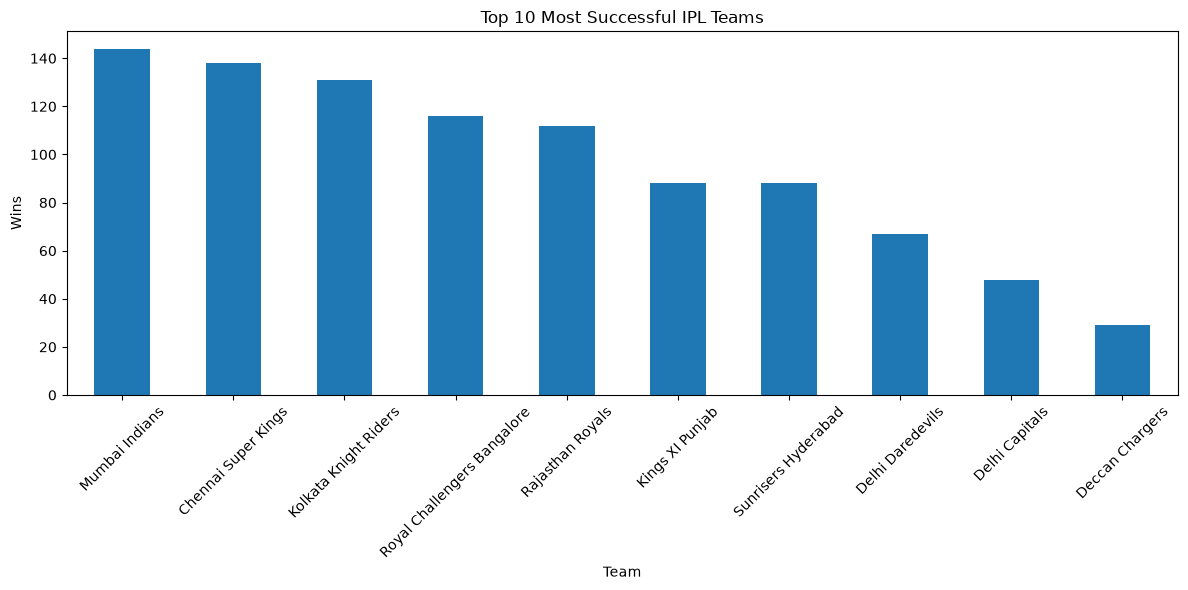

In [15]:
plt.figure(figsize=(12,6))

matches['winner'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 Most Successful IPL Teams')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../reports/images/top_teams.png')

plt.show()

In [16]:
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

In [17]:
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

In [18]:
top_players = matches['player_of_match'].value_counts().head(10)

top_players

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64

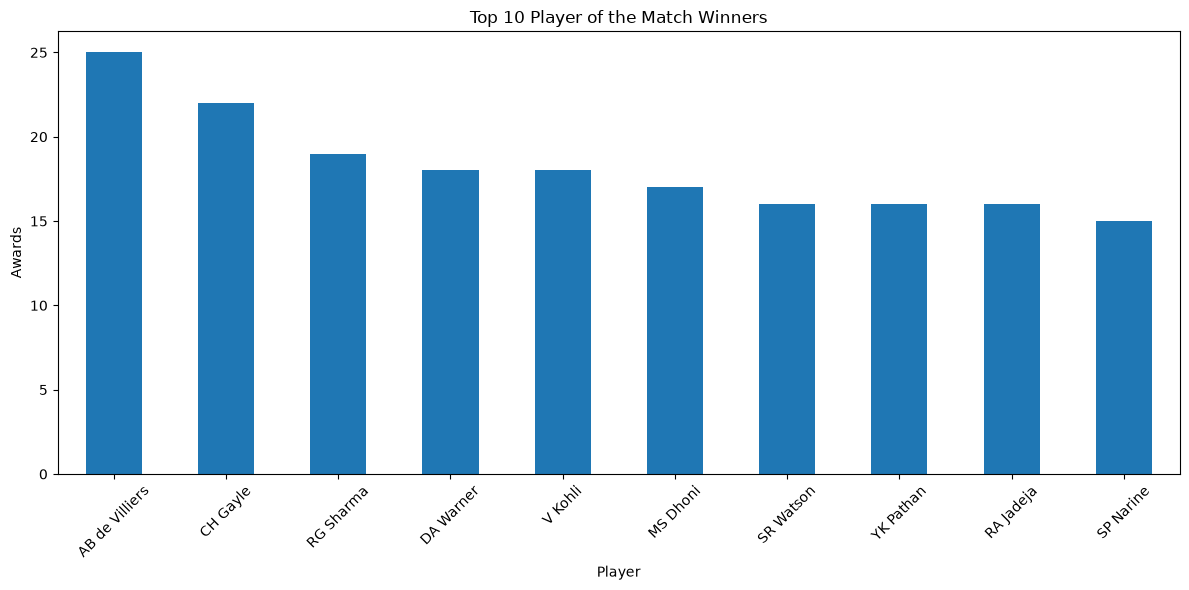

In [19]:
plt.figure(figsize=(12,6))

top_players.plot(kind='bar')

plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Player')
plt.ylabel('Awards')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../reports/images/top_players.png')

plt.show()

In [20]:
matches[['toss_winner', 'toss_decision', 'winner']].head()

,toss_winner,toss_decision,winner
0,Royal Challengers Bangalore,field,Kolkata Knight Riders
1,Chennai Super Kings,bat,Chennai Super Kings
2,Rajasthan Royals,bat,Delhi Daredevils
3,Mumbai Indians,bat,Royal Challengers Bangalore
4,Deccan Chargers,bat,Kolkata Knight Riders


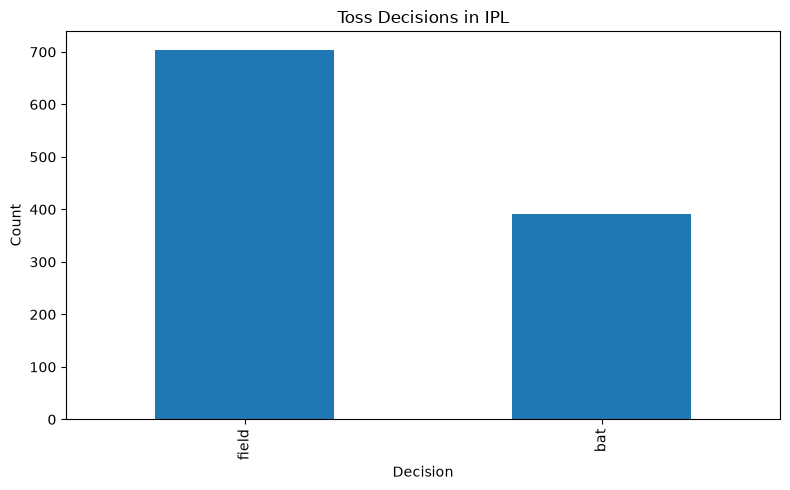

In [21]:
plt.figure(figsize=(8,5))

matches['toss_decision'].value_counts().plot(
    kind='bar'
)

plt.title('Toss Decisions in IPL')
plt.xlabel('Decision')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig('../reports/images/toss_decision.png')

plt.show()

In [22]:
toss_match_win = (
    matches['toss_winner'] == matches['winner']
).sum()

total_matches = len(matches)

print("Matches where toss winner also won match:", toss_match_win)
print("Total matches:", total_matches)

print(
    "Percentage:",
    round((toss_match_win / total_matches) * 100, 2),
    "%"
)

Matches where toss winner also won match: 554
Total matches: 1095
Percentage: 50.59 %


In [23]:
top_venues = matches['venue'].value_counts().head(10)

top_venues

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

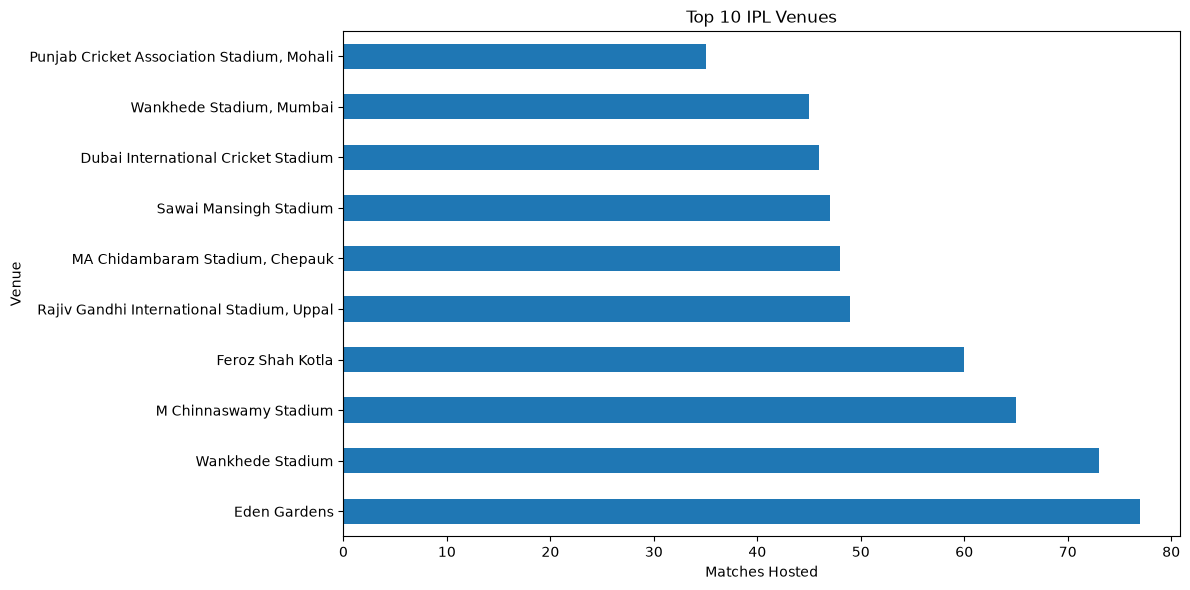

In [24]:
plt.figure(figsize=(12,6))

top_venues.plot(kind='barh')

plt.title('Top 10 IPL Venues')
plt.xlabel('Matches Hosted')
plt.ylabel('Venue')

plt.tight_layout()

plt.savefig('../reports/images/top_venues.png')

plt.show()

In [25]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [26]:
top_batsmen = deliveries.groupby(
    'batter'
)['batsman_runs'].sum().sort_values(
    ascending=False
).head(10)

top_batsmen

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

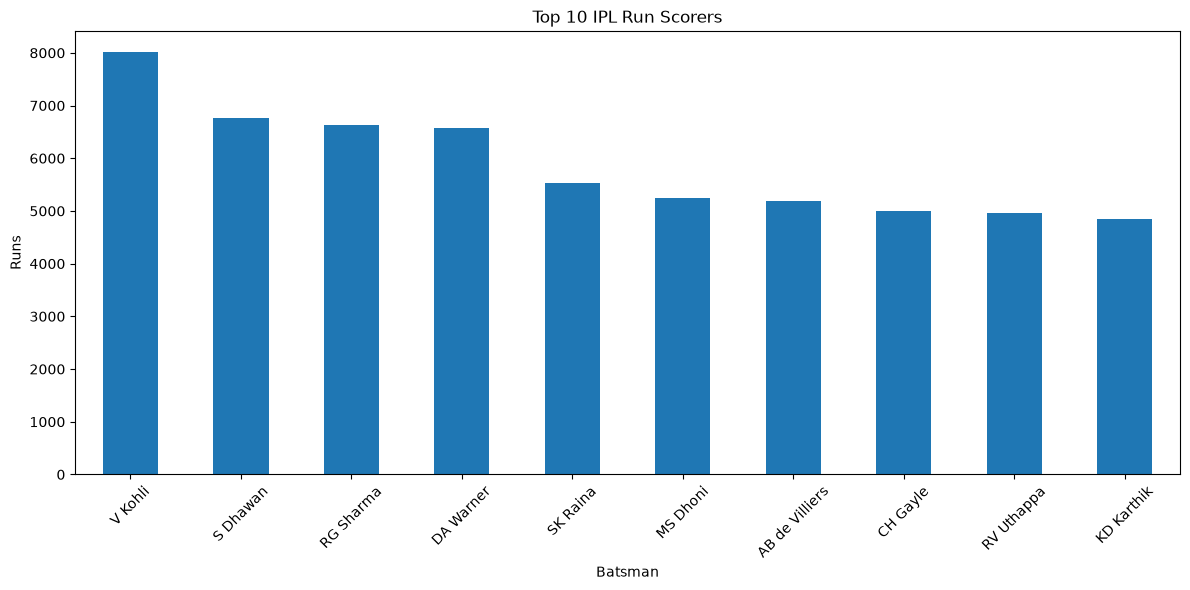

In [27]:
plt.figure(figsize=(12,6))

top_batsmen.plot(kind='bar')

plt.title('Top 10 IPL Run Scorers')
plt.xlabel('Batsman')
plt.ylabel('Runs')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../reports/images/top_batsmen.png')

plt.show()

In [28]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

In [29]:
top_bowlers = deliveries[
    deliveries['player_dismissed'].notna()
]['bowler'].value_counts().head(10)

top_bowlers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64

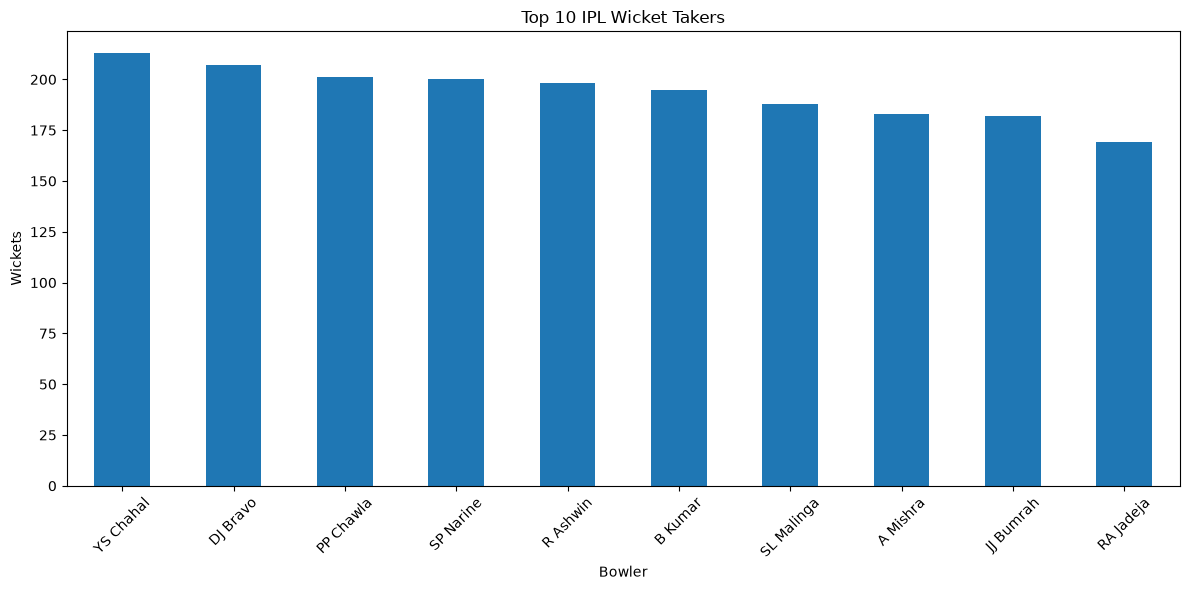

In [30]:
plt.figure(figsize=(12,6))

top_bowlers.plot(kind='bar')

plt.title('Top 10 IPL Wicket Takers')
plt.xlabel('Bowler')
plt.ylabel('Wickets')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../reports/images/top_bowlers.png')

plt.show()